In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from collections import Counter

In [2]:
dir = "E:\\study\\Engineering\\FYP\\dataset\\archive\\attacks_csv\\02-14-2018\\"

In [ ]:
# FILE PATHS - UPDATE THESE
BENIGN_FILE = dir + "02-14-2018_benign.csv"      # benign file
ATTACK_FILE = dir + "02-14-2018_ftp_bruteforce.csv"  # attack file

print(f"Processing {ATTACK_FILE} vs {BENIGN_FILE}")

# Step 1: Load and prepare data
print("\nLoading data...")

# Load benign
benign_df = pd.read_csv(BENIGN_FILE)
benign_df['Target'] = 0  # Benign = 0
print(f"Benign samples: {len(benign_df):,}")

# Load attack  
attack_df = pd.read_csv(ATTACK_FILE)
attack_df['Target'] = 1  # Attack = 1
print(f"Attack samples: {len(attack_df):,}")

# Balance: 1:1 ratio (equal attack/benign)
n_samples = min(len(attack_df), len(benign_df))
benign_sample = benign_df.sample(n=n_samples, random_state=42)
dataset = pd.concat([attack_df, benign_sample], ignore_index=True)

print(f"Final dataset: {len(dataset):,} samples (1:1 balanced)")
print(f"Class balance: {Counter(dataset['Target'])}")

# Step 2: Prepare features
print("\n Preparing features...")

# Select numeric features only (exclude metadata)
exclude_cols = ['Target', 'Label', 'FlowID', 'Src IP', 'Dst IP', 'Timestamp', 'Flow ID']
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

X = dataset[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = dataset['Target']

print(f"Features: {len(feature_cols)}")
# print(f"Sample features: {feature_cols[:5].tolist()}")

# Step 3: Run RFECV
print("\n🚀 Running RFECV...")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scaler = StandardScaler()

rfecv = RFECV(
    estimator=rf,
    step=2,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    min_features_to_select=5
)

X_scaled = scaler.fit_transform(X)
rfecv.fit(X_scaled, y)

🔍 Processing E:\study\Engineering\FYP\dataset\archive\attacks_csv\02-14-2018\02-14-2018_ftp_bruteforce.csv vs E:\study\Engineering\FYP\dataset\archive\attacks_csv\02-14-2018\02-14-2018_benign.csv

📊 Loading data...
Benign samples: 667,626
Attack samples: 193,360
Final dataset: 386,720 samples (1:1 balanced)
Class balance: Counter({1: 193360, 0: 193360})

🔧 Preparing features...
Features: 78

🚀 Running RFECV...


,estimator,RandomForestC...ndom_state=42)
,step,2
,min_features_to_select,5
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_weighted'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None



✅ RESULTS:
Total features: 78
Optimal features: 5
Reduction: 15.6x
Peak F1 score: 1.000

🏆 TOP SELECTED FEATURES:
1. Dst Port
2. Flow Pkts/s
3. Bwd Pkts/s
4. Init Fwd Win Byts
5. Fwd Seg Size Min

📈 FINAL PERFORMANCE:
Accuracy:  1.000
F1 Score:  1.000
Precision: 1.000
Recall:    1.000


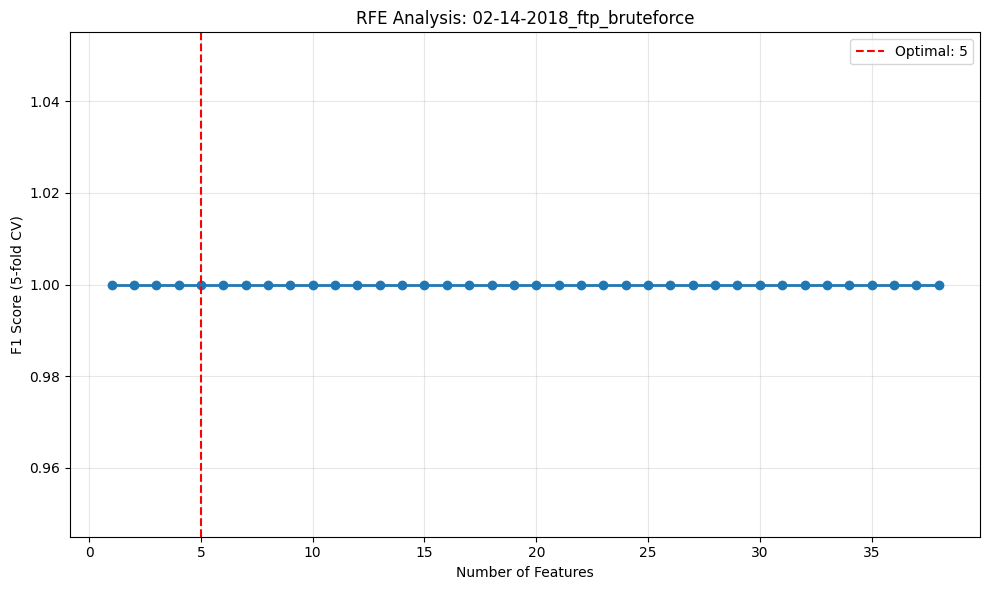


💾 Results saved:
  - 02-14-2018_ftp_bruteforce_features.csv
  - 02-14-2018_ftp_bruteforce_rfe_curve.png


In [4]:
# Step 4: Results
print("\n✅ RESULTS:")
print(f"Total features: {X.shape[1]}")
print(f"Optimal features: {rfecv.n_features_}")
print(f"Reduction: {X.shape[1]/rfecv.n_features_:.1f}x")
print(f"Peak F1 score: {np.max(rfecv.cv_results_['mean_test_score']):.3f}")

# Selected features
selected_features = np.array(feature_cols)[rfecv.support_]
print(f"\n🏆 TOP SELECTED FEATURES:")
for i, feature in enumerate(selected_features[:10], 1):
    print(f"{i}. {feature}")

# Final model evaluation
X_optimal = X_scaled[:, rfecv.support_]
final_scores = cross_validate(rf, X_optimal, y, 
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring=['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted'])

print(f"\n📈 FINAL PERFORMANCE:")
print(f"Accuracy:  {np.mean(final_scores['test_accuracy']):.3f}")
print(f"F1 Score:  {np.mean(final_scores['test_f1_weighted']):.3f}")
print(f"Precision: {np.mean(final_scores['test_precision_weighted']):.3f}")
print(f"Recall:    {np.mean(final_scores['test_recall_weighted']):.3f}")

# Step 5: Plot RFECV curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'], marker='o', linewidth=2)
plt.fill_between(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
                rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
                rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'], 
                alpha=0.2)
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_}')
plt.xlabel('Number of Features')
plt.ylabel('F1 Score (5-fold CV)')
from pathlib import Path

attack_file_stem = Path(ATTACK_FILE).stem

plt.title(f'RFE Analysis: {attack_file_stem}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{attack_file_stem}_rfe_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 6: Save results
results_df = pd.DataFrame({
    'feature': feature_cols,
    'selected': rfecv.support_,
    'ranking': rfecv.ranking_
}).sort_values('ranking')

results_df[results_df['selected'] == True].to_csv(f'{attack_file_stem}_features.csv', index=False)
print(f"\n💾 Results saved:")
print(f"  - {attack_file_stem}_features.csv")
print(f"  - {attack_file_stem}_rfe_curve.png")